## Q1. A CSV file (students.csv) contains information about students, including
Study Hours, Attendance (%), and Exam Marks.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [6]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IBM TRANING/StudentsPerformance.csv')

In [7]:
print("Missing values per column before removal:")
print(df.isnull().sum())

Missing values per column before removal:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
df = df.dropna()

In [9]:
marks = df['math score'].to_numpy()

mean_marks = np.mean(marks)
median_marks = np.median(marks)
std_marks = np.std(marks)

print(f"\n--- Statistics for Exam Marks ---")
print(f"Mean: {mean_marks:.2f}")
print(f"Median: {median_marks:.2f}")
print(f"Standard Deviation: {std_marks:.2f}")


--- Statistics for Exam Marks ---
Mean: 66.09
Median: 66.00
Standard Deviation: 15.16


In [10]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Frequency')

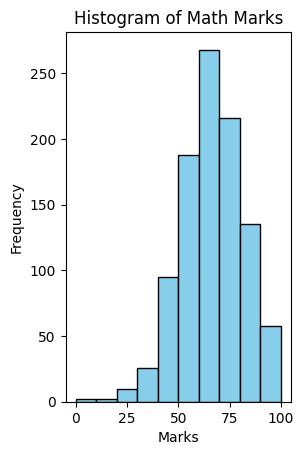

In [11]:
plt.subplot(1, 2, 1)
plt.hist(df['math score'], bins=10, color='skyblue', edgecolor='black')
plt.title('Histogram of Math Marks')
plt.xlabel('Marks')
plt.ylabel('Frequency')

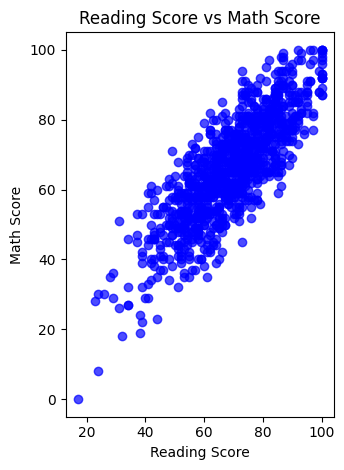

In [12]:
plt.subplot(1, 2, 2)
plt.scatter(df['reading score'], df['math score'], color='blue', alpha=0.7, label='Actual Data')
plt.title('Reading Score vs Math Score')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.tight_layout()
plt.show()

In [13]:
X = df[['reading score']] # Independent variable (Feature)
y = df['math score']    # Dependent variable (Target)

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [14]:
y_pred = model.predict(X)

In [15]:
print(f"\n--- Regression Model Outputs ---")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print("\nFirst 5 Predicted vs Actual Values:")
for i in range(min(5, len(df))):
    print(f"Study Hours: {X.iloc[i, 0]:.1f} -> Predicted: {y_pred[i]:.2f}, Actual: {y.iloc[i]:.2f}")


--- Regression Model Outputs ---
Intercept: 7.36
Coefficient (Slope): 0.85

First 5 Predicted vs Actual Values:
Study Hours: 72.0 -> Predicted: 68.49, Actual: 72.00
Study Hours: 90.0 -> Predicted: 83.78, Actual: 69.00
Study Hours: 95.0 -> Predicted: 88.02, Actual: 90.00
Study Hours: 57.0 -> Predicted: 55.76, Actual: 47.00
Study Hours: 78.0 -> Predicted: 73.59, Actual: 76.00


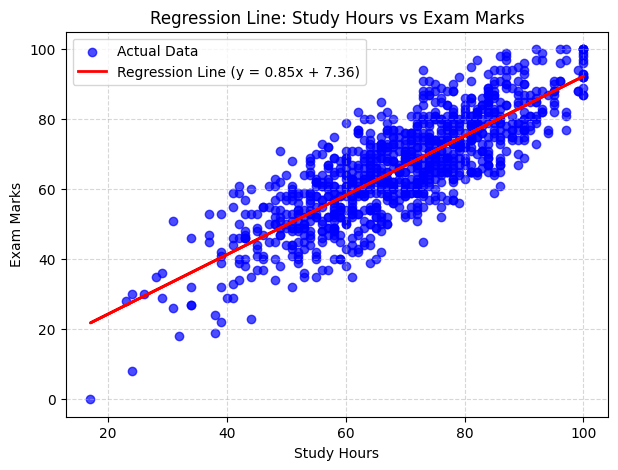

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regression Line (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})')
plt.title('Regression Line: Study Hours vs Exam Marks')
plt.xlabel('Study Hours')
plt.ylabel('Exam Marks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()